# ODE 2 notebook

## Systems of 2 variables

Consider the system of equations:

$$
\frac{dx}{dt} = xy-x
$$

and

$$
\frac{dy}{dt} = y-xy+\sin^2(\omega t)
$$

We want to solve them for $0 \leq t \leq 10$ with $\omega = 1$ and $x = y = 1$ at $t = 0$


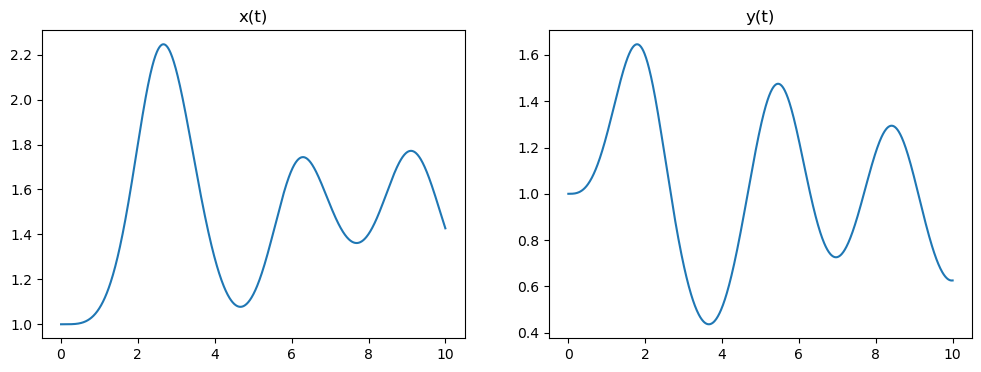

In [23]:
import numpy as np 
import matplotlib.pyplot as plt 

def f(r, t):
    x = r[0]
    y = r[1]
    fx = x*y-x
    fy = y-x*y+np.sin(t)**2

    return np.array([fx, fy], dtype="float")

# Single step of RK4 method
def RK_step(f, r_0, h, t_0):
    k1 = h*f(r_0, t_0)
    k2 = h*f(r_0+0.5*k1, t_0+0.5*h)
    k3 = h*f(r_0+0.5*k2, t_0+0.5*h)
    k4 = h*f(r_0+k3, t_0+h)
    r = r_0 + (k1+2*k2+2*k3+k4)/6
    return r

a = 0.0
b = 10.0
N = 1000
h = (b-a)/N

# Create time array
time = np.linspace(a, b, num=N)

# Create empty x and y arrays
x = np.empty(N)
y = np.empty(N)
x[0] = 1.0
y[0] = 1.0

# Create empty r array and initialize first point to (x, y) = (1, 1)
r = np.empty((N,2), dtype='float')
r[0,:] = np.array([x[0], y[0]])

for i in range(N-1):
    r[i+1,:] = RK_step(f, r[i,:], h, time[i])
    x[i+1] = r[i+1,0]
    y[i+1] = r[i+1,1]

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(time, x)
axes[0].set_title("x(t)")
axes[1].plot(time, y)
axes[1].set_title("y(t)")

plt.show()

Be careful with the indexing in these kinds of solution. Since we are setting the first element of the array, we only need to consider N-1 points in the loop. 

## Second order (and higher) ODE's

We address higher order ODE's by treating the intermediate derivatives as additional variables. For example, 
consider a physical pendulum. This is similar to the simple pendulum you studied in Introduction to Mechanics 
without the small angle approximation. This modifies the differential equation to:

$$
\frac{d^2\theta}{dt^2} = -\frac{g}{l}\sin(\theta)
$$

Here, we use:

$$
\frac{d\theta}{dt} = \omega
$$

We can rewrite these as a set of equations:

$$
\frac{d\theta}{dt} = \omega = f_x(r, t)
$$

$$
\frac{d\omega}{dt} = -\frac{g}{l}\sin(\theta) = f_y(r, t)
$$

with 

$$
r = (\theta, \omega)
$$

We solve this below for a pendulum of length $l = 0.1$ with $g = 9.8$. Our initial conditions are $\theta = \theta_{max}$ and $\omega = 0$ at $t = 0$. 
We model the motion from $t = 0$ to $t = 5$. We compare the result to the known solution for the 
simple pendulum with the solution:

$$
\theta(t) = \theta_{max}\cos\left(\sqrt{\frac{g}{l}}t\right)
$$

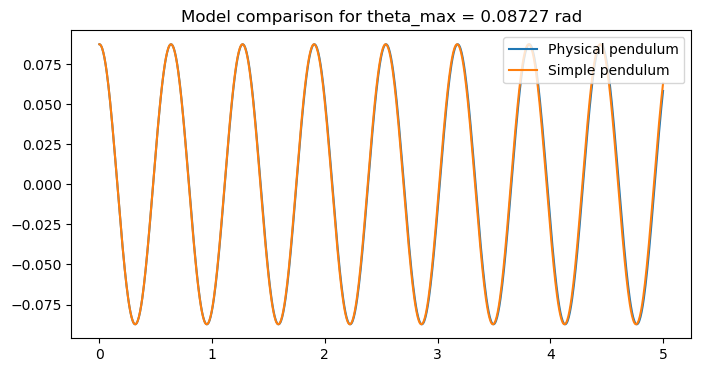

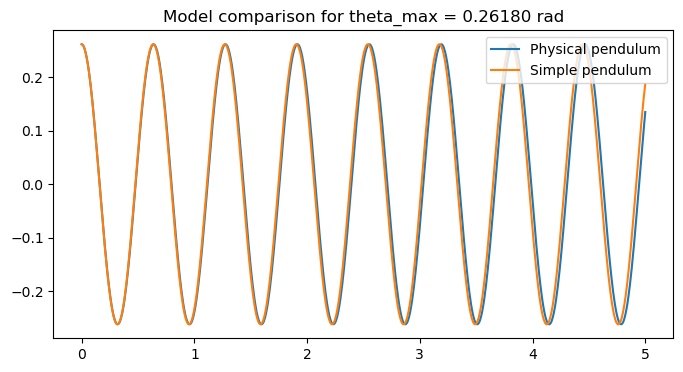

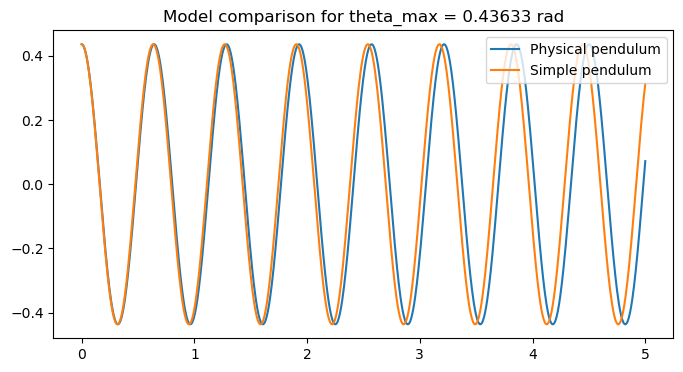

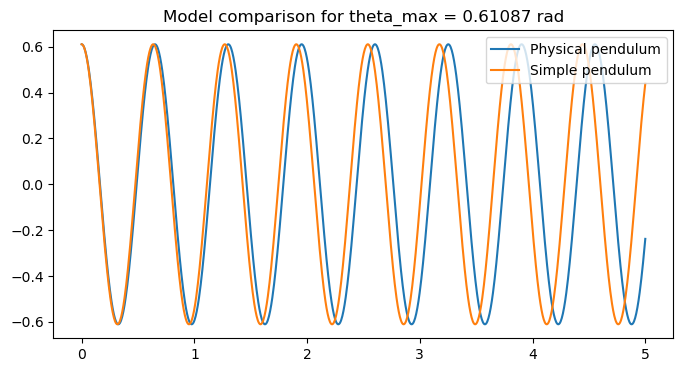

In [24]:
import numpy as np 
import matplotlib.pyplot as plt 

def f(r, t):
    theta = r[0]
    omega = r[1]
    fx = omega
    fy = -98*np.sin(theta)
    return np.array([fx, fy])

def solve(f, theta_init, h, time):

    N = time.size

    # Create theta and omega arrays and initialize
    theta = np.empty(N, dtype='float')
    omega = np.empty(N, dtype='float')
    theta[0] = theta_init
    omega[0] = 0

    # Create and initialize r array
    r = np.empty((N,2), dtype='float')
    r[0,:] = np.array([theta[0], omega[0]])

    for i in range(N-1):
        r[i+1, :] = RK_step(f, r[i,:], h, time[i])
        theta[i+1] = r[i+1,0]
        omega[i+1] = r[i+1,1]

    return [theta, omega]

N = 1000
a = 0
b = 5
h = (b-a)/N

# Create time array
time = np.linspace(a, b, num=N)

theta_max = np.array([5, 15, 25, 35])*np.pi/180

for tm in theta_max:
    fig, axes = plt.subplots(1, 1, figsize=(8,4))
    theta, omega = solve(f, tm, h, time)
    axes.plot(time, theta, label="Physical pendulum")
    axes.plot(time, tm*np.cos(np.sqrt(98)*time), label="Simple pendulum")
    axes.set_title(f"Model comparison for theta_max = {tm:.5f} rad")
    axes.legend(loc='upper right')

plt.show()

As expected, we find that the physical pendulum's answer agrees with the simple pendulum for small amplitudes ($\theta_{max}$). As the amplitude gets larger, the small angle approximation that is part of the simple pendulum becomes less accurate and the solution gets worse.

## Adaptive method

In the example above, we considered starting angles up to 35 degrees. As the angle increases, we can see that the function is getting steeper. This will result in a poorer accuracy in the Runge-Kutta method. We can apply the adaptive method to find the error at each step:

$$
\delta = \frac{1}{30}(x_1-x_2)
$$



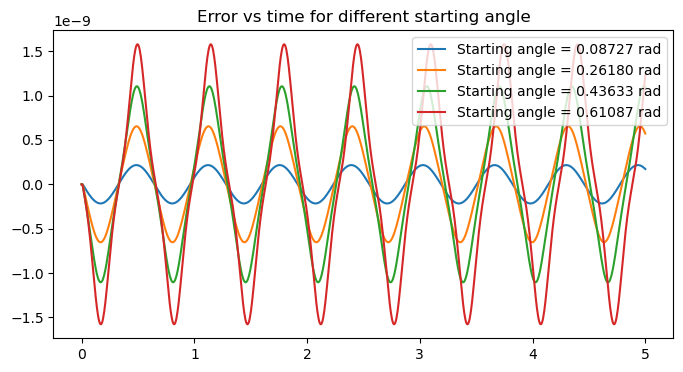

In [44]:
import time as mtime

def calc_error(f, r_0, t_0, h):
    # 2 steps
    r_1 = RK_step(f, RK_step(f, r_0, h, t_0), h, t_0+h)
    theta_1 = r_1[0]

    # 1 step
    r_2 = RK_step(f, r_0, 2*h, t_0)
    theta_2 = r_2[0]

    return (theta_1-theta_2)/30.0

N = 1000
a = 0
b = 5
h = (b-a)/N

# Create time array
time = np.linspace(a, b, num=N)

theta_max = np.array([5, 15, 25, 35])*np.pi/180

fig, axes = plt.subplots(1, 1, figsize=(8,4))

for tm in theta_max:
    # Calculate the angular position
    start = mtime.time()
    theta, omega = solve(f, tm, h, time)
    stop = mtime.time()
    ref_time = stop-start
    
    # Calculate the error
    error = np.empty(N)
    for i in range(N-2):
        error[i+2] = calc_error(f, np.array([theta[i], omega[i]]), time[i], h)

    axes.plot(time, error, label=f"Starting angle = {tm:.5f} rad")

axes.set_title("Error vs time for different starting angle")
axes.legend(loc='upper right')
plt.show()

As expected, the error in each step grows larger as the starting amplitude increases. That error can build up throughout the calculation. 

If we want to cap the maximum value of the error, we have to use an adaptive method as done below. There, we set the maximum evolution of the error in time to $\Delta = 10^{-7}$ per second so that each step have a max error of $\delta' = \Delta h'$. For scale, at $h = 0.01$, this gives a max error per step of $10^{-9}$.

The original code with 1000 points took 0.013378381729125977 s to run. The adaptive method with 1943.0 points and more calculates too 0.11681127548217773 s. That's a x8.731345677472243 increase.


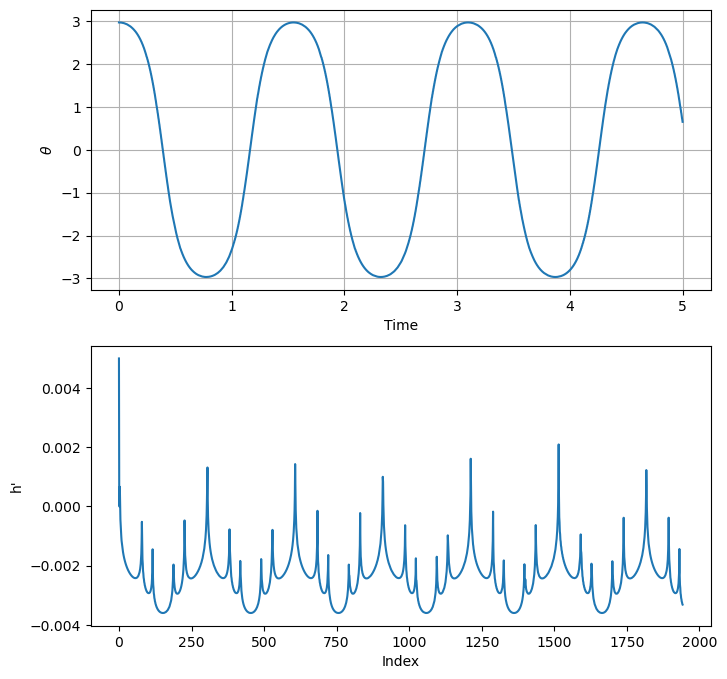

In [48]:
def solve_adaptive(f, theta_init, h, N, t_0, t_max, error_rate):

    time = np.array([t_0])

    h_current = h

    # Create theta and omega arrays and initialize
    theta = np.array([theta_init])
    omega = np.array([0.0])

    # Create and initialize r array
    r = np.array([[theta[0], omega[0]]])

    r = np.vstack([r, RK_step(f, r[0,:], h_current, time[0])])
    time = np.append(time, time[-1]+h_current)

    i = 0

    while time[-1] < t_max:
        # 2 steps
        r_1 = RK_step(f, RK_step(f, r[i,:], h_current, time[-1]), h_current, time[-1]+h_current)
        # 1 step
        r_2 = RK_step(f, r[i,:], 2*h_current, time[-1])
        # r[i+2,:] = r_1
        # h' 
        rho = 30*h_current*error_rate/np.abs(r_1[0]-r_2[0])
        hp = h_current*rho**0.25 

        # Compare h' to h_current 
        if hp >= h_current:
            r = np.vstack([r, r_1])
            time = np.append(time, time[-1]+h_current)
            h_current = hp
        else:
            h_current = hp
            r = np.vstack([r, RK_step(f, RK_step(f, r[i,:], h_current, time[-1]), h_current, time[-1]+h_current)])
            time = np.append(time, time[-1]+h_current)

        i += 1

    return r, time


N = 1000
a = 0
b = 5
h = (b-a)/N

theta_max = 170.0*np.pi/180.0

start = mtime.time()
r, time = solve_adaptive(f, theta_max, h, N, a, b, 1e-8)
stop = mtime.time()
ref_time_2 = stop-start

# Create a array of differences between hp and starting h
hp = np.array([h])
hp = np.append(hp, np.array([time[i+1]-time[i]-h for i in range(time.size-1)]))

print(f"The original code with 1000 points took {ref_time} s to run. The adaptive method with {r.size/2} points and more calculates too {ref_time_2} s. That's a x{ref_time_2/ref_time} increase.")

fig, axes = plt.subplots(2, 1, figsize=(8,8))
axes[0].plot(time, r[:,0])
axes[0].set_xlabel("Time")
axes[0].set_ylabel(r"$\theta$")
axes[0].grid()

axes[1].plot(np.arange(time.size), hp)
axes[1].set_xlabel("Index")
axes[1].set_ylabel("h'")

plt.show()

Notice that the calculation required over 1800 points. Adjusting the value of $\Delta$ up or down would decrease or increase the number of points. 